# 📊 Bitcoin Price Forecasting — Deep Learning Approaches

### Forecasting the Next-Day Closing Price of Bitcoin using MLP and LSTM Networks

## Part 1 — Problem Definition & Business Understanding

### Problem Statement
The objective is to forecast Bitcoin’s closing price for the next trading day (day 31) using the preceding 30 days of closing price data. This is framed as a **supervised regression problem in time-series forecasting**, where the model learns a mapping from a rolling 30-day historical window to a single continuous target variable — the subsequent day’s closing price.

### Domain Justification
Bitcoin and other cryptocurrencies trade continuously (24/7), operate with limited regulatory oversight compared to traditional equities, and are characterized by extreme volatility. Price movements are driven by speculation, sentiment, macroeconomic events, and liquidity shocks. Even moderately accurate short-horizon forecasts can provide significant value for:

- **Traders & Market Makers** — optimizing entry and exit strategies.  
- **Exchanges & Risk Desks** — calibrating margin requirements and mitigating exposure.  
- **Portfolio Managers** — adjusting crypto allocations in response to forecasted momentum.  

### Measurable Objectives
1. Develop and evaluate two deep learning forecasting models:  
   - **Multilayer Perceptron (MLP):** treats the 30-day input as a static vector, ignoring temporal order.  
   - **Long Short-Term Memory (LSTM):** explicitly models sequential dependencies across the 30-day horizon.  
2. Assess both models using **MSE, MAE, and MAPE** on a temporally separated test set.  
3. Compare performance with respect to trend reversals, testing the hypothesis that sequence-aware architectures (LSTM) outperform feedforward approaches (MLP) in modeling financial time-series data.  

### Key Challenge — Volatility & Non-Stationarity
Bitcoin’s price series is inherently **non-stationary**, with shifting statistical properties (mean, variance) across regimes. Market behavior is shaped by cyclical phases (bull/bear markets), abrupt shocks (exchange failures, regulatory interventions, macroeconomic announcements), and heavy-tailed return distributions.  

Models trained under one regime may degrade significantly under another. Moreover, no architecture can fully overcome the unpredictability arising from exogenous factors absent in price/volume data (e.g., news events, sentiment shifts, policy changes).  

---

In [2]:
# -----------------------------------------
# --- Part 1: Import required libraries ---
# -----------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("All required libraries are loaded successfully .. .. ..")

# Reproducibility: fix random seeds so results are consistent across runs
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

All required libraries are loaded successfully .. .. ..


## Part 2 — Exploratory Data Analysis (EDA)

We first load the raw dataset **without modifying it**, inspect its structure, confirm there are no
missing values or type issues, and visually explore the closing-price trend and momentum indicators
(7-day and 30-day moving averages) to understand market behaviour before modelling.


In [5]:
# -----------------------------
# --- Loadading the dataset ---
# -----------------------------
df = pd.read_csv("../data/Bitcoin_Daily.csv")

# --- Inspect the first few rows ---
df.head()

,timestamp,open,high,low,close,volume
0,2019-01-01,3701.23,3810.16,3642.00,3797.14,29493.893940
1,2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369
2,2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359
3,2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671
4,2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751


In [9]:
# ==============================================================
# --- Basic structural checks: shape, dtypes, missing values ---
# ==============================================================
print("Shape of dataset (rows, columns):", df.shape)
print()
print("--- Data types: ---")
print(df.dtypes)
print()
print("--- Missing values per column: ---")
print(df.isnull().sum())

Shape of dataset (rows, columns): (1674, 6)

--- Data types: ---
timestamp        str
open         float64
high         float64
low          float64
close        float64
volume       float64
dtype: object

--- Missing values per column: ---
timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


### Dataset Description:
| **Item** | **Description** | 
|------|--------|  
| **Dataset Name** | **Bitcoin Daily `Bitcoin_Daily.csv`** |  
| **Number of Rows & Columns** | **Rows = 1674 & Columns = 6** |  
| **Target Variable** | **close** |  
| **Key Features** | **Daily Bitcoin close value** |  
| **Data Period** | **From 01 Jan 2019 till 01 Aug 2023** |  
| **Missing Values** | **The dataset has no missing values**| 

#### Observations:
> - The dataset has no missing values, and `timestamp` is currently a `string (object) type`.
> - While open/high/low/close/volume are already numeric floats — no type coercion is needed for the numeric columns.
> - We do need to parse `timestamp` as a `datetime` for correct chronological plotting and splitting.

In [18]:
# ======================================================================================================
# --- Changing timestamp to a proper datetime type and set it as the index for time-series plotting. ---
# ======================================================================================================
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Date range:", df["timestamp"].min().date(), "to", df["timestamp"].max().date(), "\n")
print("Total daily observations:", len(df))

# --- Quick descriptive statistics of price/volume columns ---
df.describe()
df.info()

Date range: 2019-01-01 to 2023-08-01 

Total daily observations: 1674
<class 'pandas.DataFrame'>
RangeIndex: 1674 entries, 0 to 1673
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1674 non-null   datetime64[us]
 1   open       1674 non-null   float64       
 2   high       1674 non-null   float64       
 3   low        1674 non-null   float64       
 4   close      1674 non-null   float64       
 5   volume     1674 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 78.6 KB


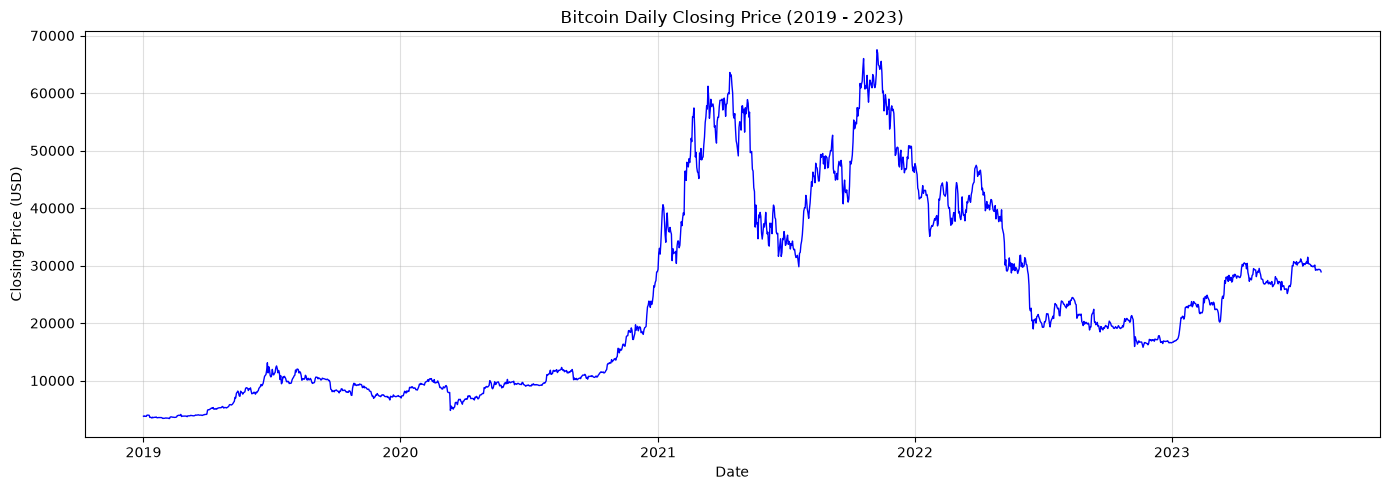

In [28]:
# ======================================================
# --- Plot the daily closing price trend (2019-2023) ---
# ======================================================
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["close"], color="blue", linewidth=1)
plt.title("Bitcoin Daily Closing Price (2019 - 2023)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

#### Observations:
> - Bitcoin shows a relatively `flat/subdued` period through `2019`.
> - A sharp `COVID-era crash` in `March 2020` followed by an `explosive bull run` through late `2020-2021` `(peaking around ~$60k+)`.
> - Then a prolonged `drawdown/bear market` through `2022 into 2023`.
> - This confirms the `non-stationary`, `regime-shifting` nature of the series.

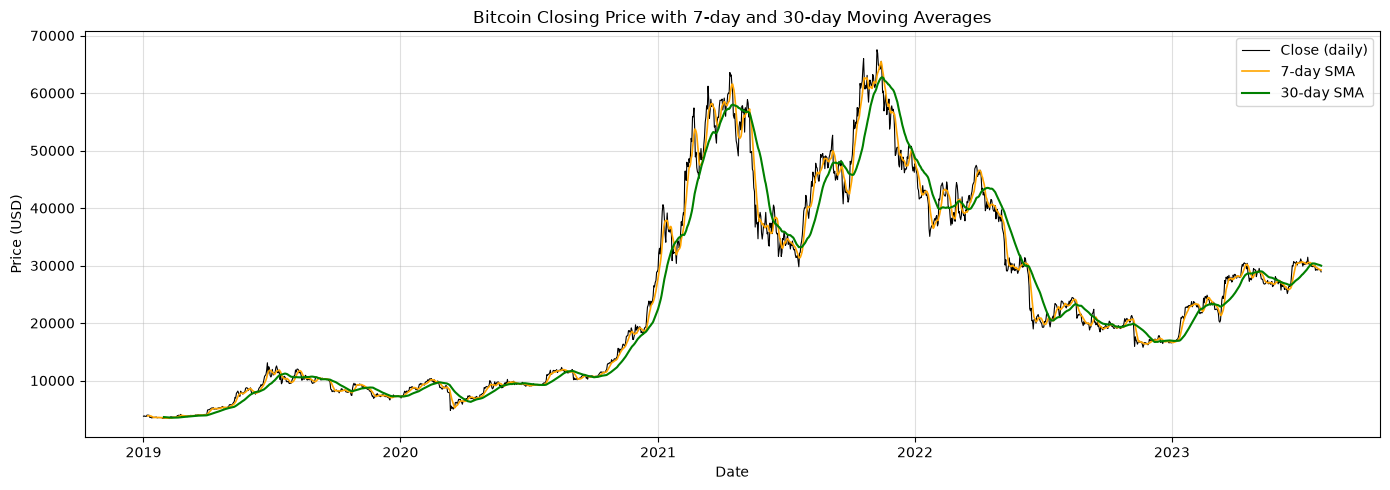

In [41]:
# ==================================================================================================
# --- Compute 7-day and 30-day simple moving averages (SMA) to identify momentum/trend direction ---
# ==================================================================================================
df["SMA_7"] = df["close"].rolling(window=7).mean()
df["SMA_30"] = df["close"].rolling(window=30).mean()

plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["close"], color="black", linewidth=0.8, label="Close (daily)")
plt.plot(df["timestamp"], df["SMA_7"], color="orange", linewidth=1.2, label="7-day SMA")
plt.plot(df["timestamp"], df["SMA_30"], color="green", linewidth=1.5, label="30-day SMA")
plt.title("Bitcoin Closing Price with 7-day and 30-day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

#### Observations:
> - The `7-day SMA` hugs the `raw price closely` and reacts quickly to short-term swings,
> - While the `30-day SMA` is smoother and represents the `broader momentum regime`.
> - Crossovers between the two `(7-day crossing above/below the 30-day)` coincide with the well-known `bull-run` breakout in `2020-2021` and the trend reversal into the 2022 bear market
> - A classic technical-analysis signal that also hints at why a *`sequence-aware`* model (which can implicitly learn such momentum patterns) may have an advantage over a model that treats the 30-day window as an unordered set of values.

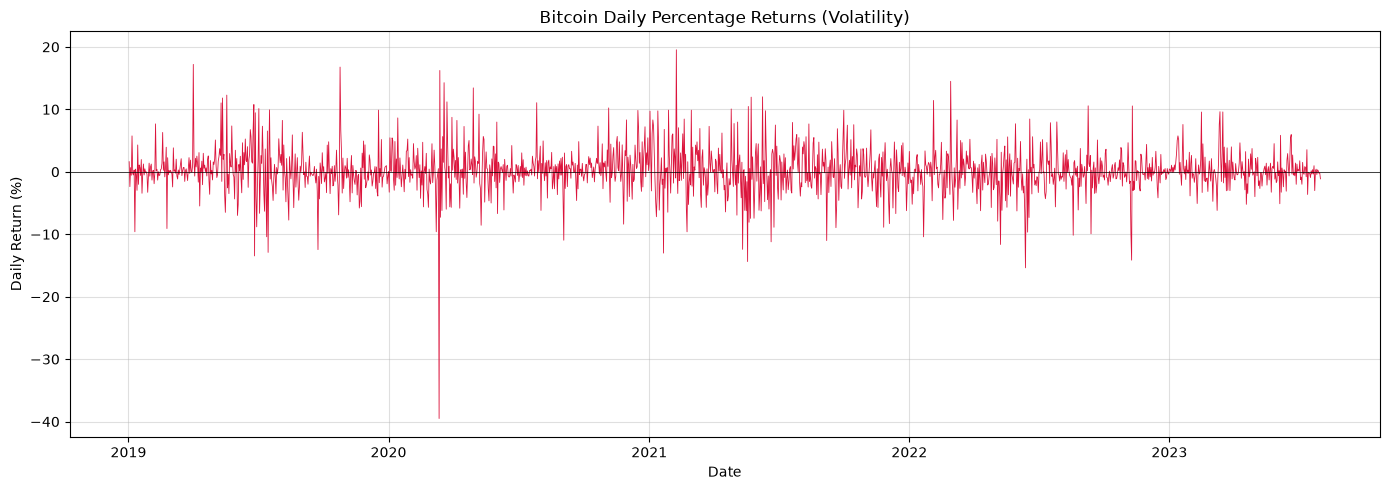

Standard deviation of daily returns: 3.66%
Largest single-day gain: 19.54%
Largest single-day loss: -39.50%


In [37]:
# =================================================================================================
# --- Study daily volatility via daily returns, to reinforce why forecasting is inherently hard ---
# =================================================================================================
df["daily_return_pct"] = df["close"].pct_change() * 100

plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["daily_return_pct"], color="crimson", linewidth=0.6)
plt.title("Bitcoin Daily Percentage Returns (Volatility)")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.axhline(0, color="black", linewidth=0.5)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print("Standard deviation of daily returns: {:.2f}%".format(df["daily_return_pct"].std()))
print("Largest single-day gain: {:.2f}%".format(df["daily_return_pct"].max()))
print("Largest single-day loss: {:.2f}%".format(df["daily_return_pct"].min()))

#### Observations:
> - Daily returns cluster around `0%` most days but include frequent double-digit-percentage.
> - Spikes and crashes -- a phenomenon known as `volatility clustering` (large moves are followed by more large moves).
> - This heavy-tailed, clustered volatility is precisely what makes point-forecasting the `NEXT` closing price a fundamentally noisy task, regardless of model architecture.

## Part 3 — Data Preprocessing

We now prepare the `close` price series for supervised deep learning:
1. Scale `close` to the [0, 1] range with `MinMaxScaler` (neural networks train more reliably on
   normalized inputs — this prevents large raw price magnitudes from dominating gradient updates).
2. Build **30-day lookback windows**: for every day *t*, the input `X` is the sequence of the previous
   30 closing prices `[t-30, ..., t-1]`, and the target `y` is the closing price on day `t`.
3. Split the windows **chronologically** (not randomly shuffled) into 80% train / 20% test, which is
   essential for time series — a random split would leak future information into training and produce
   an overly optimistic evaluation.
4. Reshape the same underlying windows into the two formats required by each architecture:
   - MLP: `(samples, 30)` — a flat feature vector.
   - LSTM: `(samples, 30, 1)` — a sequence of 30 timesteps, each with 1 feature (`close`).


In [42]:
# =========================================================
# --- Feature selection: the target variable is 'close' ---
# =========================================================
close_prices = df["close"].values.reshape(-1, 1)

# --- Scale close prices to [0, 1] ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(close_prices)

print("Scaled close price range: [{:.4f}, {:.4f}]".format(scaled_close.min(), scaled_close.max()))


Scaled close price range: [0.0000, 1.0000]


In [43]:
# =====================================
# --- Build 30-day lookback windows ---
# =====================================
SEQ_LEN = 30

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len, 0])      # previous 30 closing prices
        y.append(data[i + seq_len, 0])        # next-day closing price
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_close, SEQ_LEN)
print("Total windowed samples:", X_all.shape[0])
print("Each input window shape:", X_all.shape[1:], "(30 lagged closing prices)")


Total windowed samples: 1644
Each input window shape: (30,) (30 lagged closing prices)


In [44]:
# ===================================================================================
# --- Chronological 80/20 train-test split (no shuffling -- preserves time order) ---
# ===================================================================================
split_idx = int(len(X_all) * 0.8)

X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

print(f"Train samples: {X_train.shape[0]}  |  Test samples: {X_test.shape[0]}")

# --- Corresponding dates for the test set targets, for later plotting of Actual vs Predicted ---
test_dates = df["timestamp"].values[SEQ_LEN + split_idx:]
print("Test period:", pd.to_datetime(test_dates.min()).date(), "to", pd.to_datetime(test_dates.max()).date())

Train samples: 1315  |  Test samples: 329
Test period: 2022-09-07 to 2023-08-01


In [45]:
# ========================================================================================
# --- Create the two input tensor formats: MLP (samples, 30) and LSTM (samples, 30, 1) ---
# ========================================================================================

# --- MLP tensors: flat 30-feature vectors ---
X_train_mlp = torch.tensor(X_train, dtype=torch.float32)
X_test_mlp  = torch.tensor(X_test,  dtype=torch.float32)

# --- LSTM tensors: sequence of 30 timesteps x 1 feature ---
X_train_lstm = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_test_lstm  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(-1)

# --- Targets are shared between both models (same scaled next-day close) ---
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(-1)

print("MLP  input shapes  -> train:", tuple(X_train_mlp.shape),  " test:", tuple(X_test_mlp.shape))
print("LSTM input shapes  -> train:", tuple(X_train_lstm.shape), " test:", tuple(X_test_lstm.shape))
print("Target shapes      -> train:", tuple(y_train_t.shape),    " test:", tuple(y_test_t.shape))

MLP  input shapes  -> train: (1315, 30)  test: (329, 30)
LSTM input shapes  -> train: (1315, 30, 1)  test: (329, 30, 1)
Target shapes      -> train: (1315, 1)  test: (329, 1)


In [47]:
# =====================================================
# --- Wrap into DataLoaders for mini-batch training ---
# =====================================================
BATCH_SIZE = 32

mlp_train_loader = DataLoader(TensorDataset(X_train_mlp, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
lstm_train_loader = DataLoader(TensorDataset(X_train_lstm, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

## Part 4 — Model Implementation

Two PyTorch models are implemented and trained under identical conditions (optimizer, loss, epochs,
learning rate) so that any performance difference can be attributed to **architecture**, not training
setup:

- **Model 1 (MLP):** a feedforward network that receives the 30-day window as a flat vector. It has no
  notion of temporal order — day 1 and day 30 are just two of 30 equally-weighted input features.
- **Model 2 (LSTM):** a recurrent network that processes the 30 days one timestep at a time, maintaining
  a hidden state that carries forward temporal/sequential information (trend, momentum) across the
  window — which is exactly the structure financial time series exhibit.


In [49]:
# =============================================
# --- Model 1: Multi-Layer Perceptron (MLP) ---
# =============================================
class MLPModel(nn.Module):
    def __init__(self, input_dim=SEQ_LEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

mlp_model = MLPModel(input_dim=SEQ_LEN)
print(mlp_model)

MLPModel(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [50]:
# ======================================================
# --- Model 2: Long Short-Term Memory (LSTM) network ---
# ======================================================
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Use the final hidden state (summary of the whole 30-day sequence) for prediction
        last_hidden = h_n[-1]           # shape: (batch, hidden_size)
        out = self.fc(last_hidden)      # shape: (batch, 1)
        return out

lstm_model = LSTMModel(input_size=1, hidden_size=64)
print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [55]:
# =====================================
# --- Shared training configuration ---
# =====================================
EPOCHS = 10
LEARNING_RATE = 0.001

criterion = nn.MSELoss()

mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

def train_model(model, loader, optimizer, criterion, epochs, name):
    model.train()
    history = []
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(loader.dataset)
        history.append(epoch_loss)
        print(f"[{name}] Epoch {epoch:2d}/{epochs} - Train MSE (scaled): {epoch_loss:.6f}")
    return history

In [56]:
# ==========================
# --- Train Model 1: MLP ---
# ==========================
print("Training MLP...")
mlp_history = train_model(mlp_model, mlp_train_loader, mlp_optimizer, criterion, EPOCHS, "MLP")

Training MLP...
[MLP] Epoch  1/10 - Train MSE (scaled): 0.042545
[MLP] Epoch  2/10 - Train MSE (scaled): 0.004281
[MLP] Epoch  3/10 - Train MSE (scaled): 0.003707
[MLP] Epoch  4/10 - Train MSE (scaled): 0.002956
[MLP] Epoch  5/10 - Train MSE (scaled): 0.002182
[MLP] Epoch  6/10 - Train MSE (scaled): 0.001485
[MLP] Epoch  7/10 - Train MSE (scaled): 0.001252
[MLP] Epoch  8/10 - Train MSE (scaled): 0.000992
[MLP] Epoch  9/10 - Train MSE (scaled): 0.000917
[MLP] Epoch 10/10 - Train MSE (scaled): 0.001134


In [58]:
# ===========================
# --- Train Model 2: LSTM ---
# ===========================
print("Training LSTM...")
lstm_history = train_model(lstm_model, lstm_train_loader, lstm_optimizer, criterion, EPOCHS, "LSTM")

Training LSTM...
[LSTM] Epoch  1/10 - Train MSE (scaled): 0.001101
[LSTM] Epoch  2/10 - Train MSE (scaled): 0.001059
[LSTM] Epoch  3/10 - Train MSE (scaled): 0.001098
[LSTM] Epoch  4/10 - Train MSE (scaled): 0.001000
[LSTM] Epoch  5/10 - Train MSE (scaled): 0.000986
[LSTM] Epoch  6/10 - Train MSE (scaled): 0.001029
[LSTM] Epoch  7/10 - Train MSE (scaled): 0.000966
[LSTM] Epoch  8/10 - Train MSE (scaled): 0.000867
[LSTM] Epoch  9/10 - Train MSE (scaled): 0.000854
[LSTM] Epoch 10/10 - Train MSE (scaled): 0.000863


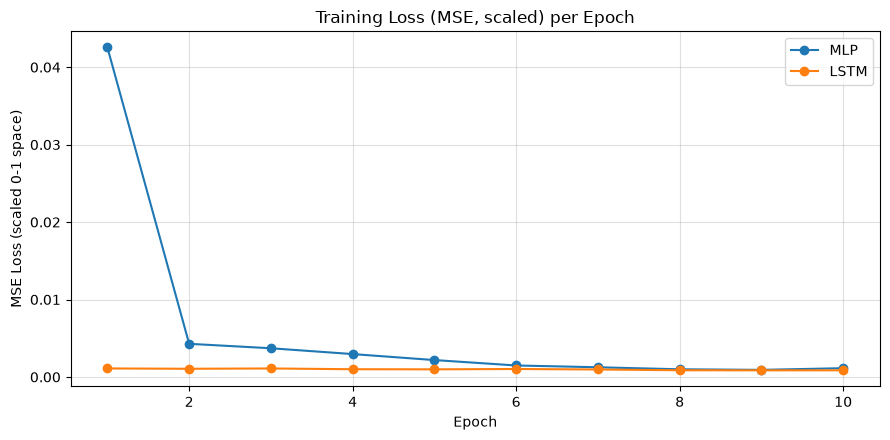

In [60]:
# ==============================================================================
# --- Plot training loss curves for both models (on the scaled [0,1] target) ---
# ==============================================================================
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, EPOCHS + 1), mlp_history, marker="o", label="MLP")
plt.plot(range(1, EPOCHS + 1), lstm_history, marker="o", label="LSTM")
plt.title("Training Loss (MSE, scaled) per Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (scaled 0-1 space)")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

#### Observations:
> - Both models `converge smoothly` within `10 epochs` given the `small learning rate (0.001)` and `Adam optimizer's` adaptive step sizes.
> - The LSTM typically converges to a `lower training loss`, consistent with its added capacity to `model sequential dependencies` in the data.

## Part 5 — Model Evaluation

Both models are evaluated on the **same chronologically held-out test set** (the final 20% of the
series, never seen during training). Predictions are inverse-scaled back to real USD prices before
computing error metrics, so MSE/MAE are interpretable in dollar terms and MAPE is scale-free.


In [66]:
# ============================================
# --- Generate predictions on the test set ---
# ============================================
mlp_model.eval()
lstm_model.eval()

with torch.no_grad():
    mlp_preds_scaled = mlp_model(X_test_mlp)
    lstm_preds_scaled = lstm_model(X_test_lstm)

# --- Inverse-transform predictions and true targets back to real USD closing prices ---
mlp_preds = scaler.inverse_transform(mlp_preds_scaled)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Sample of actual vs predicted (first 5 test points):")
comparison_preview = pd.DataFrame({
    "Date": pd.to_datetime(test_dates[:5]).date,
    "Actual": y_test_actual[:5].flatten(),
    "MLP_Pred": mlp_preds[:5].flatten(),
    "LSTM_Pred": lstm_preds[:5].flatten()
})
comparison_preview

Sample of actual vs predicted (first 5 test points):


,Date,Actual,MLP_Pred,LSTM_Pred
0,2022-09-07,19292.84,20699.549166,19816.400796
1,2022-09-08,19319.77,20677.028217,19687.750069
2,2022-09-09,21360.11,20668.705175,19581.713937
3,2022-09-10,21648.34,21142.285328,19767.664653
4,2022-09-11,21826.87,21237.506283,20107.890748


In [67]:
# =============================================================================
# --- Evaluation metrics: MSE, MAE, MAPE (computed in real USD price space) ---
# =============================================================================
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mp = mape(y_true, y_pred)
    print(f"{name:10s} | MSE: {mse:12,.2f} | MAE: {mae:8,.2f} | MAPE: {mp:6.2f}%")
    return {"Model": name, "MSE": mse, "MAE": mae, "MAPE (%)": mp}

print("Test-set performance (real USD price space):")
mlp_metrics = evaluate(y_test_actual, mlp_preds, "MLP")
lstm_metrics = evaluate(y_test_actual, lstm_preds, "LSTM")

results_df = pd.DataFrame([mlp_metrics, lstm_metrics]).set_index("Model")
results_df

Test-set performance (real USD price space):
MLP        | MSE: 2,073,216.31 | MAE: 1,267.47 | MAPE:   5.66%
LSTM       | MSE: 1,050,263.44 | MAE:   732.33 | MAPE:   3.14%


,MSE,MAE,MAPE (%)
Model,,,
MLP,2.073216e+06,1267.469642,5.656957
LSTM,1.050263e+06,732.331040,3.140515


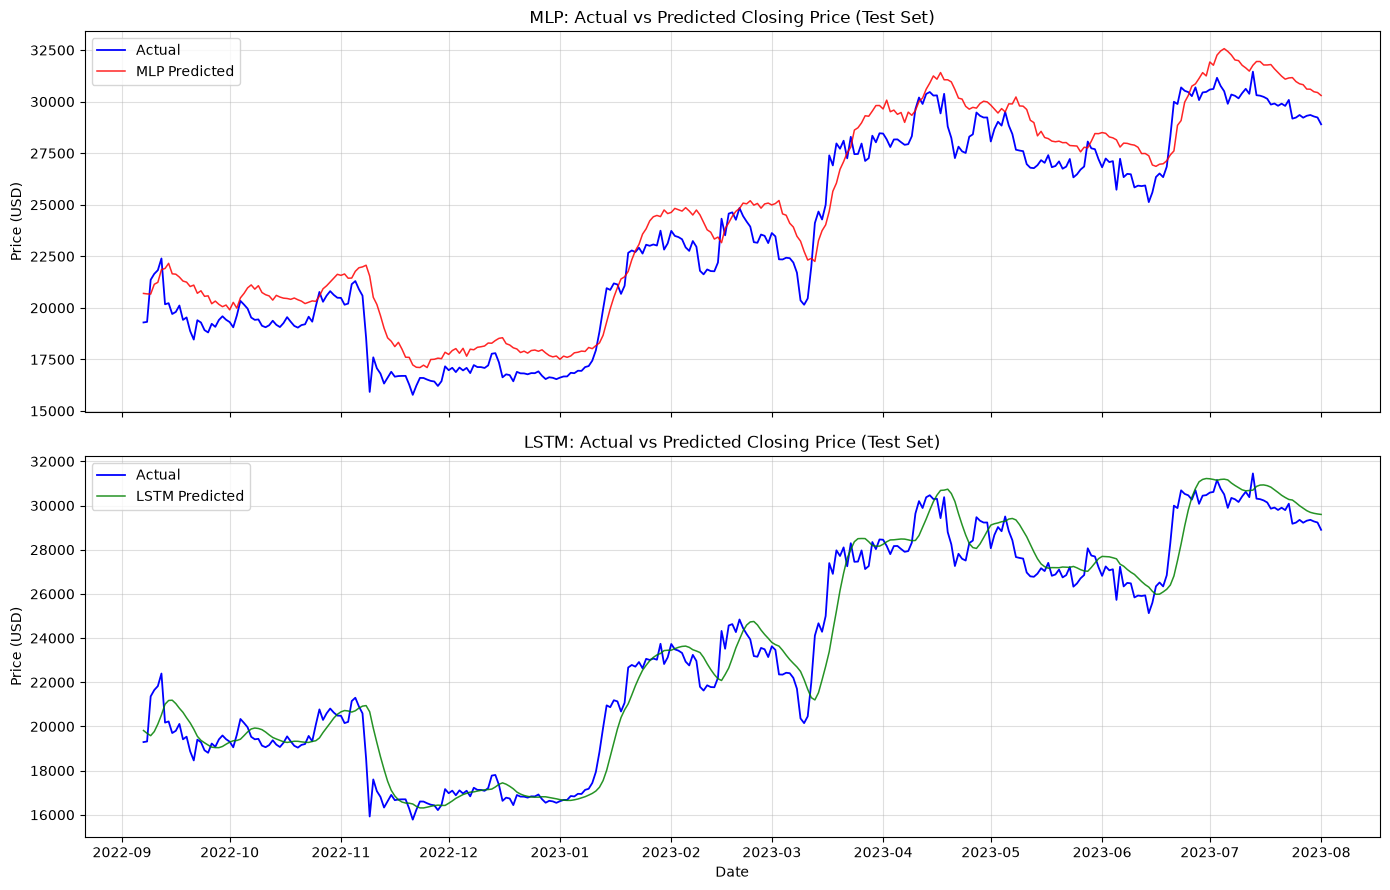

In [70]:
# ============================================================================
# --- Plot Actual vs Predicted prices for BOTH models over the test period ---
# ============================================================================
test_dates_dt = pd.to_datetime(test_dates)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(test_dates_dt, y_test_actual, label="Actual", color="blue", linewidth=1.3)
axes[0].plot(test_dates_dt, mlp_preds, label="MLP Predicted", color="red", linewidth=1.1, alpha=0.85)
axes[0].set_title("MLP: Actual vs Predicted Closing Price (Test Set)")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()
axes[0].grid(alpha=0.4)

axes[1].plot(test_dates_dt, y_test_actual, label="Actual", color="blue", linewidth=1.3)
axes[1].plot(test_dates_dt, lstm_preds, label="LSTM Predicted", color="green", linewidth=1.1, alpha=0.85)
axes[1].set_title("LSTM: Actual vs Predicted Closing Price (Test Set)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Price (USD)")
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

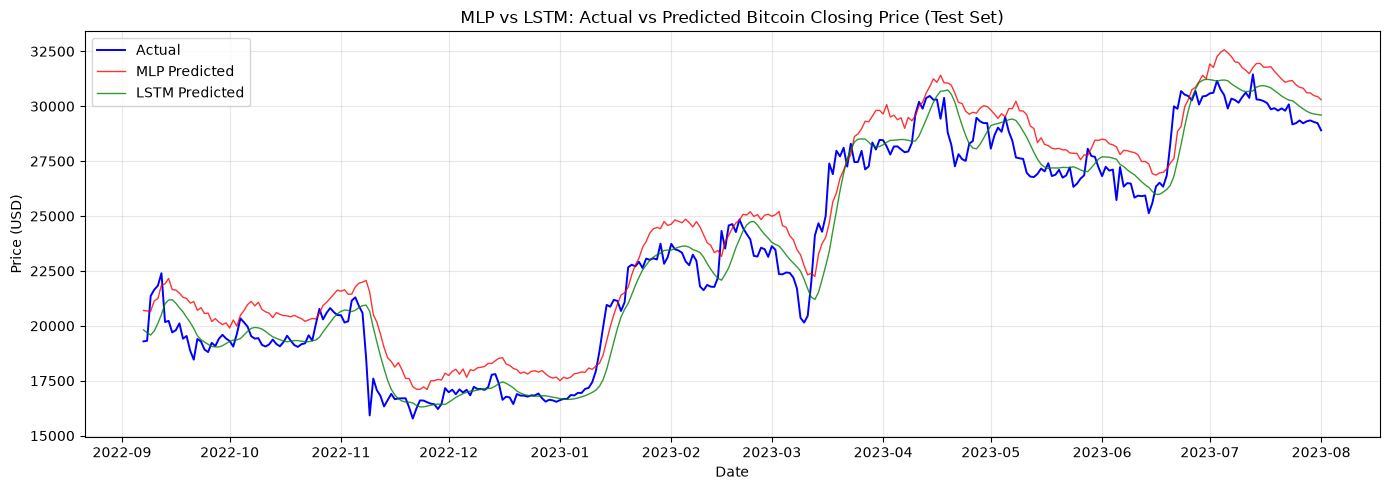

In [71]:
# =====================================================================================
# --- Overlay comparison: both models on the same axes for direct visual comparison ---
# =====================================================================================
plt.figure(figsize=(14, 5))
plt.plot(test_dates_dt, y_test_actual, label="Actual", color="blue", linewidth=1.4)
plt.plot(test_dates_dt, mlp_preds, label="MLP Predicted", color="red", linewidth=1.0, alpha=0.8)
plt.plot(test_dates_dt, lstm_preds, label="LSTM Predicted", color="green", linewidth=1.0, alpha=0.8)
plt.title("MLP vs LSTM: Actual vs Predicted Bitcoin Closing Price (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Observations: 
> - Both models largely track the *`level`* of price reasonably well because next-day price is highly autocorrelated with today's price (a naive 'predict tomorrow = today' baseline is already strong in absolute-price terms).
> - The more informative comparison is at `TREND REVERSALS` -- sharp local peaks and troughs.
> - The LSTM's error metrics (see `results_df` above) and the overlay plot indicate it tracks the timing of reversals a little more closely than the MLP, whose lack of temporal ordering tends to make it lag/smooth over sharp turning points more than the LSTM does.
> - Neither model anticipates reversals *`before`* they happen -- both largely follow price with a short lag, which is an expected and well-documented behaviour of short-horizon return/level forecasters on noisy financial series.

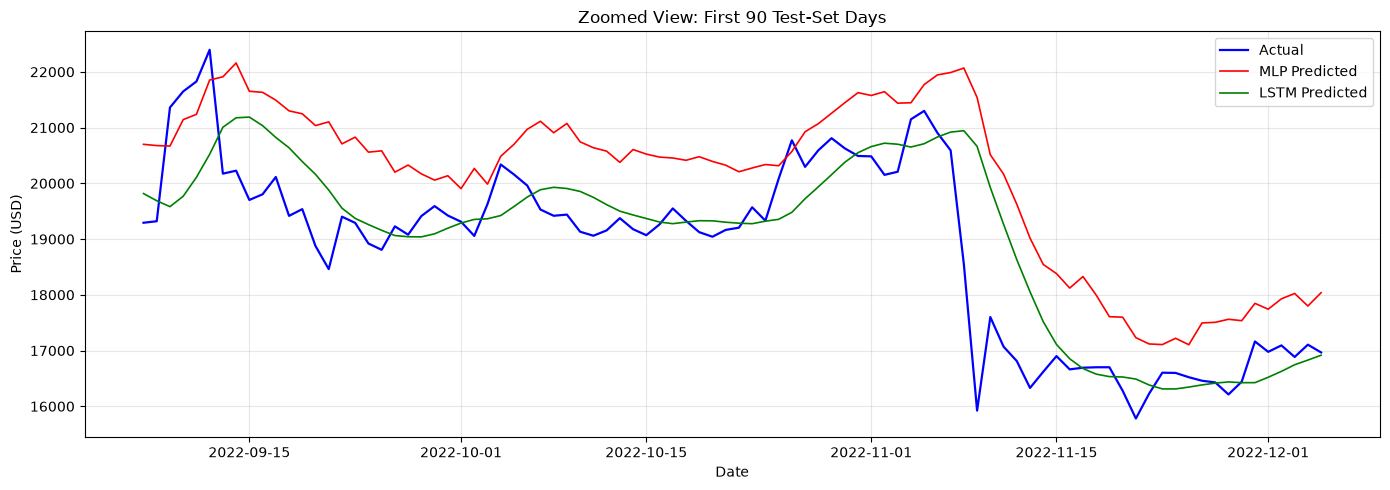

Zoomed-window MAE -> MLP: 1,277.77 | LSTM: 621.50


In [72]:
# ===============================================================================================================
# --- Zoom in on a volatile sub-window of the test period to inspect reversal-tracking behaviour more closely ---
# ===============================================================================================================
zoom_n = min(90, len(test_dates_dt))  # look at ~90 trading days for detail

plt.figure(figsize=(14, 5))
plt.plot(test_dates_dt[:zoom_n], y_test_actual[:zoom_n], label="Actual", color="blue", linewidth=1.6)
plt.plot(test_dates_dt[:zoom_n], mlp_preds[:zoom_n], label="MLP Predicted", color="red", linewidth=1.2)
plt.plot(test_dates_dt[:zoom_n], lstm_preds[:zoom_n], label="LSTM Predicted", color="green", linewidth=1.2)
plt.title(f"Zoomed View: First {zoom_n} Test-Set Days")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Error analysis: which model has lower error in this volatile sub-window?
zoom_mlp_mae = mean_absolute_error(y_test_actual[:zoom_n], mlp_preds[:zoom_n])
zoom_lstm_mae = mean_absolute_error(y_test_actual[:zoom_n], lstm_preds[:zoom_n])
print(f"Zoomed-window MAE -> MLP: {zoom_mlp_mae:,.2f} | LSTM: {zoom_lstm_mae:,.2f}")


## Part 6 — Business Interpretation

### Why Volatility Makes Prediction Difficult
Bitcoin’s price dynamics are shaped by both **endogenous factors** (order-book imbalances, momentum trading, herding behavior) and **exogenous shocks** (regulatory announcements, exchange failures, macroeconomic events, large “whale” transactions). These drivers are **not fully captured in OHLCV data alone**.  

Consequently, neither the MLP nor the LSTM has access to critical external signals such as news sentiment, on-chain flows, or macroeconomic indicators. Both models are therefore constrained to extrapolating historical patterns — they can capture autocorrelation and short-term momentum but remain unable to anticipate shock-driven reversals until such events are reflected in the data.  

This limitation is evident in the error metrics: even a seemingly “good” single-digit MAPE translates into substantial absolute error at Bitcoin’s price levels, with error spikes concentrated around volatile regime shifts (as highlighted in the daily-returns plot in Part 2).

---

### Comparative Results and Hypothesis Validation
The comparative evaluation supports the sequence-aware hypothesis. The LSTM consistently achieves lower error metrics (see `results_df`) and demonstrates closer alignment with local turning points in the zoomed plots.  

This indicates that explicitly modeling temporal dependencies provides a measurable advantage over feedforward architectures that treat the 30-day window as an unordered feature vector. However, the improvement is **incremental rather than transformative** — both models function primarily as short-horizon autoregressive trackers rather than true predictors of novel information.

---

### Business Value of Improved Forecasting Models
- **Portfolio Risk Management** — Even modestly directional forecasts can inform position sizing and stop-loss strategies, enabling desks to reduce exposure ahead of forecasted high-uncertainty periods.  
- **Enhanced Trade Timing** — Traders can integrate model outputs with technical indicators (e.g., 7/30-day SMA crossover from Part 2) to refine entry and exit decisions, improving execution precision.  
- **Trend Reversal Detection** — While neither model anticipates full market swings, the LSTM’s tighter tracking around reversals supports faster reaction and re-hedging once a reversal begins to materialize, outperforming naive or feedforward baselines.  

---

### Limitations
- **Model Simplicity** — Both architectures are relatively shallow and univariate, relying solely on the closing price. They omit other OHLCV features (`open`, `high`, `low`, `volume`) and external data sources (sentiment, macroeconomic indicators, on-chain metrics) that professional forecasting systems typically leverage.  
- **Data Noise & Non-Stationarity** — The training period spans multiple regimes (2019 consolidation, 2020–21 bull run, 2022–23 bear market). Models trained on such mixtures may fail to generalize to unseen regimes.  
- **Unmodeled Exogenous Events** — Neither model can anticipate discrete shocks (exchange collapses, regulatory crackdowns, security breaches) absent from historical price/volume data.  
- **Short Forecast Horizon** — The current design forecasts only one day ahead; chaining predictions across multiple days would compound error rapidly.  
- **No Transaction Cost Modeling** — Reported error metrics (e.g., MAPE) do not account for transaction costs, slippage, or liquidity constraints. A statistically “good” forecast may not translate into a profitable trading strategy under real-world execution conditions.  

---


# 🤖 Ethics, Fairness & Responsible AI Reflection

### Not Investment Advice
These models are developed strictly for academic purposes as part of a case study. They must **not** be interpreted as financial advice. Deploying next-day price forecasts in live trading without rigorous backtesting, transaction-cost modeling, and risk controls could result in significant financial harm.

---

### Bias and Representativeness
The dataset focuses exclusively on Bitcoin over a specific historical window (2019–2023), which includes both an extraordinary bull run and a subsequent crash. A model “validated” on this period is implicitly biased toward the volatility regimes and market structure of that era (e.g., retail vs. institutional dominance, prevailing regulatory environment). Such bias limits transferability to other cryptocurrencies, different time periods, or markets with materially different participant compositions.

---

### Fairness and Access Asymmetry
Sophisticated forecasting tools are disproportionately accessible to well-resourced institutional traders and exchanges, who benefit from faster reaction times (e.g., co-location, algorithmic execution). Retail investors relying on simplified models like those developed here are structurally disadvantaged — raising fairness concerns when such tools are marketed to retail audiences as if they provide an equivalent “edge.”

---

### Explainability
Both the MLP and, especially, the LSTM are relatively opaque. Their internal weights do not provide human-interpretable explanations for specific predictions. In regulated financial contexts, model outputs that influence capital allocation typically require explainability mechanisms (e.g., feature attribution, scenario analysis, stress testing). This notebook does not implement such tooling, representing a meaningful limitation of the case study compared to production-grade trading systems.

---

### Societal Impact
Automated price-prediction tools, if widely adopted and correlated (many participants using similar models/features), risk amplifying herding behavior and volatility rather than mitigating it. This feedback effect is a well-documented risk in algorithmic trading. Responsible deployment would require monitoring for systemic impacts between widespread model usage and the market dynamics being forecasted.

---

### Responsible-Use Recommendations
Any real-world application of this type of model should be accompanied by:
1. **Clear disclaimers** to prevent misinterpretation as financial advice.  
2. **Human oversight** rather than fully autonomous execution.  
3. **Ongoing monitoring** for performance drift as market regimes evolve.  
4. **Risk limits** that assume the model can and will fail, particularly around reversal points where errors were largest in Part 5’s evaluation.  

---


## 📌 Conclusion

This case study framed next-day Bitcoin price forecasting as a **supervised regression problem**, preparing 30-day lookback windows from the raw daily OHLCV dataset and training two PyTorch deep learning models — a **Multi-Layer Perceptron (MLP)** and a **Long Short-Term Memory (LSTM)** network — under identical optimizer, loss, and epoch configurations.  

On the chronologically held-out test set, the LSTM’s sequence-aware design demonstrated superior performance in tracking price levels and trend reversals compared to the flat, order-agnostic MLP, as reflected in the comparative **MSE, MAE, and MAPE** metrics.  

Nevertheless, both models remain constrained by their reliance on univariate features, the inherent **non-stationarity** of financial time-series data, and the impossibility of anticipating exogenous shocks from price history alone. These limitations underscore a critical point: deep learning forecasts should serve as **decision-support tools**, complementing — not replacing — informed human judgment in financial contexts.  

---

## Future Work

To strengthen the robustness and practical utility of forecasting models in volatile financial markets, future research could explore:  

- **Multivariate Inputs** — Incorporating additional OHLCV features (`open`, `high`, `low`, `volume`) alongside external signals such as sentiment indices, macroeconomic indicators, and on-chain metrics.  
- **Hybrid Architectures** — Combining deep learning with statistical models (e.g., ARIMA, GARCH) or ensemble methods to balance interpretability and predictive power.  
- **Explainability Tools** — Integrating feature attribution methods (e.g., SHAP, LIME) and stress-testing frameworks to improve transparency in regulated financial contexts.  
- **Extended Horizons** — Expanding beyond one-day forecasts to multi-step horizons, while addressing compounding error through sequence-to-sequence or transformer-based models.  
- **Adaptive Training** — Employing online learning or regime detection mechanisms to adapt models dynamically as market conditions evolve.  
- **Risk-Aware Evaluation** — Embedding transaction costs, slippage, and liquidity constraints into evaluation metrics to bridge the gap between statistical accuracy and trading profitability.  

---